# Question 1: Dataset Preparation

In this project, the Dog vs Cat dataset is downloaded from the provided GitHub repository.

The dataset contains separate training and testing directories, with two classes:
- Cats
- Dogs

In [ ]:
# Download the Dog vs Cat dataset
!git clone https://github.com/laxmimerit/dog-cat-full-dataset.git

Cloning into 'dog-cat-full-dataset'...
remote: Enumerating objects: 25059, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 25059 (delta 4), reused 6 (delta 2), pack-reused 25048 (from 1)
Receiving objects: 100% (25059/25059), 541.54 MiB | 18.80 MiB/s, done.
Resolving deltas: 100% (21/21), done.
Updating files: 100% (24990/24990), done.


In [ ]:
#Import Libraries and Define Paths
import tensorflow as tf
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score
from tensorflow.keras import layers, models, regularizers

# Dataset paths
DATASET_DIR = Path("dog-cat-full-dataset/data")

TRAIN_DIR = DATASET_DIR / "train"
TEST_DIR = DATASET_DIR / "test"

# Configuration
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

# TensorFlow AUTOTUNE for efficient data loading
AUTOTUNE = tf.data.AUTOTUNE

In [ ]:
# Load training dataset: 80%
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

# Load validation dataset: 20%
val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

Found 19989 files belonging to 2 classes.
Using 15992 files for training.
Found 19989 files belonging to 2 classes.
Using 3997 files for validation.


In [ ]:
# Load the independent test dataset
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)
class_names = train_ds.class_names

print("Class Names:", class_names)

Found 5000 files belonging to 2 classes.
Class Names: ['cats', 'dogs']


In [ ]:
# Normalize pixel values from [0, 255] to [0, 1]
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(
    lambda x, y: (normalization_layer(x), y),
    num_parallel_calls=AUTOTUNE
)

val_ds = val_ds.map(
    lambda x, y: (normalization_layer(x), y),
    num_parallel_calls=AUTOTUNE
)

test_ds = test_ds.map(
    lambda x, y: (normalization_layer(x), y),
    num_parallel_calls=AUTOTUNE
)

# Optimize input pipelines using prefetch
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

In [ ]:
def count_samples(dataset):
    return sum(images.shape[0] for images, _ in dataset)


train_samples = count_samples(train_ds)
val_samples = count_samples(val_ds)
test_samples = count_samples(test_ds)

print("=" * 50)
print("DATASET INFORMATION")
print("=" * 50)

print(f"Class names       : {class_names}")
print(f"Training samples  : {train_samples}")
print(f"Validation samples: {val_samples}")
print(f"Test samples      : {test_samples}")

DATASET INFORMATION
Class names       : ['cats', 'dogs']
Training samples  : 15992
Validation samples: 3997
Test samples      : 5000


In [ ]:
# Take one batch from the training dataset
sample_images, sample_labels = next(iter(train_ds))

print("Image batch shape:", sample_images.shape)
print("Minimum pixel value:", tf.reduce_min(sample_images).numpy())
print("Maximum pixel value:", tf.reduce_max(sample_images).numpy())

Image batch shape: (32, 224, 224, 3)
Minimum pixel value: 0.0
Maximum pixel value: 1.0


# Question 2: Data Augmentation

Data augmentation creates modified versions of existing training images to increase
data diversity and improve the model's ability to generalize.

The augmentation pipeline includes:
- Random Flip
- Random Rotation
- Random Zoom
- Random Translation

Augmentation will be applied only to the training data.

In [ ]:
# Question 2: Data Augmentation

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.3),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomTranslation(
        height_factor=0.1,
        width_factor=0.1
    )
], name="data_augmentation")

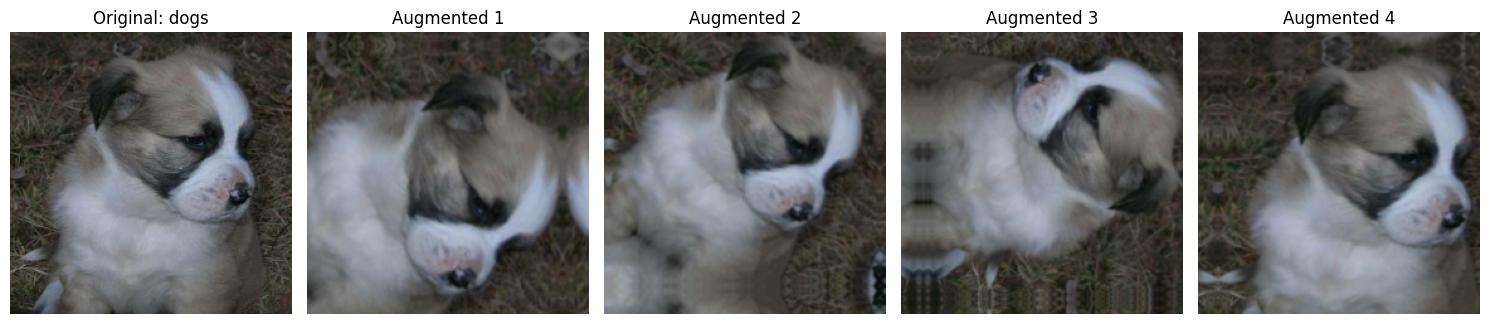

In [ ]:
# Display one original image alongside four augmented versions

images, labels = next(iter(train_ds))

original_image = images[0]

plt.figure(figsize=(15, 4))

plt.subplot(1, 5, 1)
plt.imshow(original_image.numpy())
plt.title(f"Original: {class_names[labels[0].numpy()]}")
plt.axis("off")

for i in range(4):
    augmented_image = data_augmentation(
        tf.expand_dims(original_image, axis=0),
        training=True
    )[0]

    plt.subplot(1, 5, i + 2)
    plt.imshow(augmented_image.numpy())
    plt.title(f"Augmented {i + 1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Question 3: Custom CNN Model

A Convolutional Neural Network (CNN) is built from scratch for binary
classification of cats and dogs.

The model includes:
- Data augmentation
- Three convolutional blocks
- Batch Normalization
- MaxPooling
- Dropout
- Dense classification layer
- Sigmoid output

The model is trained using EarlyStopping to prevent unnecessary training
and restore the best model weights.

In [ ]:
# Q3: Build Custom CNN Model

custom_model = models.Sequential([

    layers.Input(shape=(224, 224, 3)),

    # --------------------------------------------------------
    # Data Augmentation
    # Applied only during training automatically
    # --------------------------------------------------------
    data_augmentation,

    # --------------------------------------------------------
    # Convolutional Block 1
    # --------------------------------------------------------
    layers.Conv2D(
        32, (3, 3),
        padding="same",
        kernel_initializer="he_normal"
    ),
    layers.BatchNormalization(),
    layers.Activation("relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.20),

    # --------------------------------------------------------
    # Convolutional Block 2
    # --------------------------------------------------------
    layers.Conv2D(
        64, (3, 3),
        padding="same",
        kernel_initializer="he_normal"
    ),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    layers.Conv2D(
        64, (3, 3),
        padding="same",
        kernel_initializer="he_normal"
    ),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # --------------------------------------------------------
    # Convolutional Block 3
    # --------------------------------------------------------
    layers.Conv2D(
        128, (3, 3),
        padding="same",
        kernel_initializer="he_normal"
    ),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    layers.Conv2D(
        128, (3, 3),
        padding="same",
        kernel_initializer="he_normal"
    ),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.30),

    # --------------------------------------------------------
    # Convolutional Block 4
    # --------------------------------------------------------
    layers.Conv2D(
        256, (3, 3),
        padding="same",
        kernel_initializer="he_normal"
    ),
    layers.BatchNormalization(),
    layers.Activation("relu"),

    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.35),

    # --------------------------------------------------------
    # Classification Head
    # --------------------------------------------------------
    layers.GlobalAveragePooling2D(),

    layers.Dense(
        128,
        activation="relu",
        kernel_regularizer=regularizers.l2(1e-4)
    ),

    layers.BatchNormalization(),
    layers.Dropout(0.40),

    # Binary classification
    layers.Dense(1, activation="sigmoid")
])


# Display architecture
custom_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 609,153 (2.32 MB)

 Trainable params: 607,553 (2.32 MB)

 Non-trainable params: 1,600 (6.25 KB)

In [ ]:
# ============================================================
# COMPILE THE CUSTOM CNN
# ============================================================

custom_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
# ============================================================

# EARLY STOPPING
# ============================================================

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [ ]:
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

In [ ]:
# ============================================================
# TRAIN THE IMPROVED CUSTOM CNN
# ============================================================

history_custom_model = custom_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[
        early_stopping,
        reduce_lr
    ]
)

Epoch 1/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 144s 264ms/step - accuracy: 0.5892 - loss: 0.7202 - val_accuracy: 0.6140 - val_loss: 0.6570 - learning_rate: 0.0010
Epoch 2/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 132s 258ms/step - accuracy: 0.6434 - loss: 0.6465 - val_accuracy: 0.5994 - val_loss: 0.7368 - learning_rate: 0.0010
Epoch 3/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 129s 258ms/step - accuracy: 0.6838 - loss: 0.6050 - val_accuracy: 0.6420 - val_loss: 0.6410 - learning_rate: 0.0010
Epoch 4/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 129s 258ms/step - accuracy: 0.7072 - loss: 0.5807 - val_accuracy: 0.6392 - val_loss: 0.6466 - learning_rate: 0.0010
Epoch 5/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 129s 259ms/step - accuracy: 0.7185 - loss: 0.5641 - val_accuracy: 0.7298 - val_loss: 0.5423 - learning_rate: 0.0010
Epoch 6/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 130s 259ms/step - accuracy: 0.7277 - loss: 0.5482 - val_accuracy: 0.7431 - val_loss: 0.5255 - learning_rate: 0.0010
Epoch 7/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 130s 260ms/step - accura

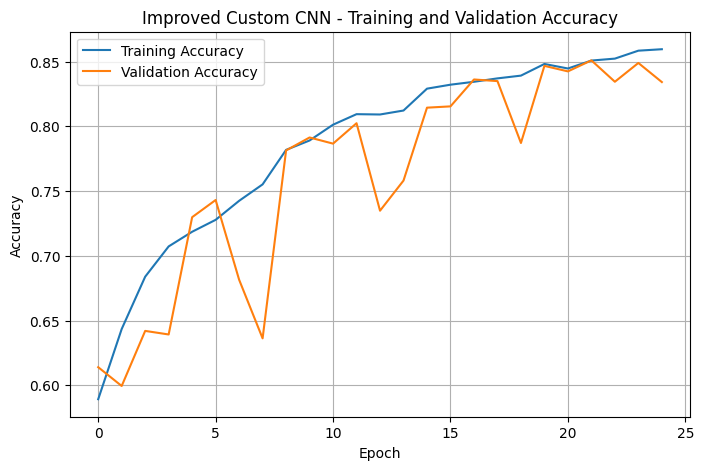

In [ ]:
# ============================================================
# TRAINING AND VALIDATION ACCURACY
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history_custom_model.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_custom_model.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Improved Custom CNN - Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

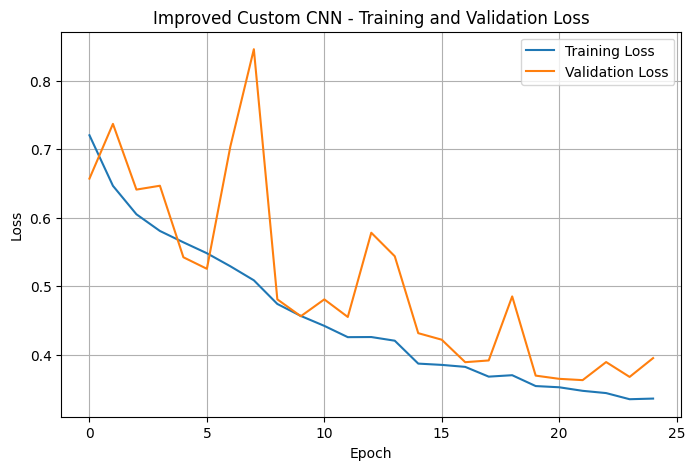

In [ ]:
# ============================================================
# TRAINING AND VALIDATION LOSS
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history_custom_model.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_custom_model.history["val_loss"],
    label="Validation Loss"
)

plt.title("Improved Custom CNN - Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

# Question 4: Transfer Learning / Feature Extraction

In this experiment, EfficientNetB0 pretrained on ImageNet is used as a
feature extractor for binary dog-versus-cat classification.

The original classification layer is removed and replaced with a new
classification head. The pretrained EfficientNetB0 backbone is frozen,
so only the newly added classification layers are trained.

Because the images from Question 1 are already normalized to the range
[0, 1], the input is rescaled to [0, 255] before being passed to
EfficientNetB0.

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_3 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,668 (16.07 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

Trainable backbone layers: 0
Total backbone layers: 238
Epoch 1/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 87s 114ms/step - accuracy: 0.9887 - loss: 0.0358 - val_accuracy: 0.9900 - val_loss: 0.0320
Epoch 2/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 28s 55ms/step - accuracy: 0.9946 - loss: 0.0184 - val_accuracy: 0.9900 - val_loss: 0.0298
Epoch 3/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 28s 55ms/step - accuracy: 0.9954 - loss: 0.0139 - val_accuracy: 0.9915 - val_loss: 0.0320
Epoch 4/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 27s 55ms/step - accuracy: 0.9964 - loss: 0.0122 - val_accuracy: 0.9895 - val_loss: 0.0406
Epoch 5/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 29s 58ms/step - accuracy: 0.9969 - loss: 0.0087 - val_accuracy: 0.9905 - val_loss: 0.0386


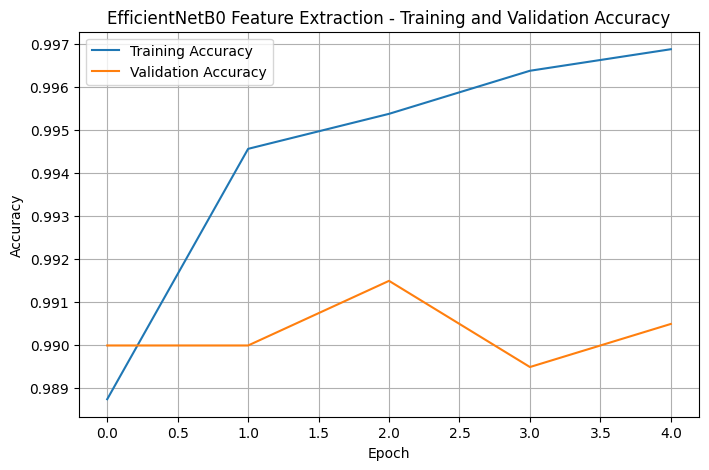

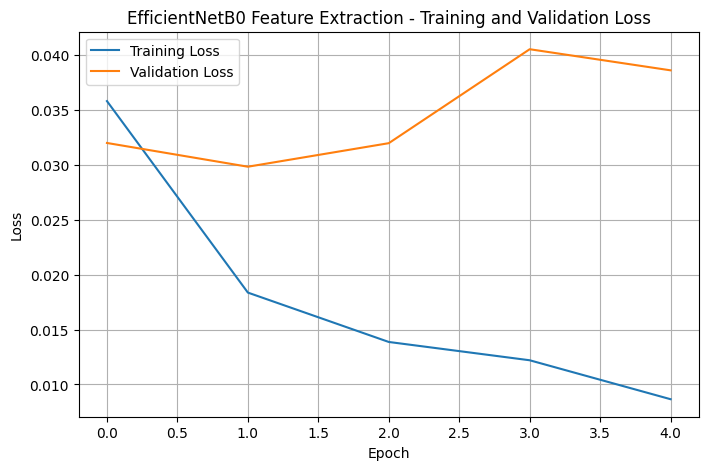

In [ ]:
# ============================================================
# QUESTION 4: TRANSFER LEARNING / FEATURE EXTRACTION
# ============================================================
import tensorflow as tf
import matplotlib.pyplot as plt

# Load EfficientNetB0 with pretrained ImageNet weights
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    input_shape=(224, 224, 3),
    weights="imagenet"
)

# Freeze all pretrained backbone layers
base_model.trainable = False


# ============================================================
# Build Feature Extraction Model
# ============================================================
#
# Q1 normalized the images to [0, 1].
# EfficientNetB0 pretrained weights are used with its
# expected input scale, so convert [0,1] back to [0,255]
# before passing the images to the pretrained backbone.
# ============================================================

feature_extraction_model = tf.keras.Sequential([

    tf.keras.layers.Input(
        shape=(224, 224, 3)
    ),

    # Convert normalized [0,1] images back to [0,255]
    tf.keras.layers.Rescaling(255.0),

    # Frozen pretrained EfficientNetB0 backbone
    base_model,

    # Global feature vector
    tf.keras.layers.GlobalAveragePooling2D(),

    # New classification head
    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),

    tf.keras.layers.Dropout(0.3),

    # Binary classification
    tf.keras.layers.Dense(
        1,
        activation="sigmoid"
    )
])


feature_extraction_model.summary()


# ============================================================
# Verify Backbone is Frozen
# ============================================================

print(
    "Trainable backbone layers:",
    sum(
        layer.trainable
        for layer in base_model.layers
    )
)

print(
    "Total backbone layers:",
    len(base_model.layers)
)


# ============================================================
# Compile the Feature Extraction Model
# ============================================================

feature_extraction_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


# ============================================================
# EarlyStopping
# ============================================================

early_stopping_feature = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)


# ============================================================
# Train Only the New Classification Head
# ============================================================

history_feature_extraction = (
    feature_extraction_model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=30,
        callbacks=[early_stopping_feature]
    )
)


# ============================================================
# Training and Validation Accuracy
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history_feature_extraction.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_feature_extraction.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title(
    "EfficientNetB0 Feature Extraction - "
    "Training and Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid(True)

plt.show()


# ============================================================
# Training and Validation Loss
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    history_feature_extraction.history["loss"],
    label="Training Loss"
)

plt.plot(
    history_feature_extraction.history["val_loss"],
    label="Validation Loss"
)

plt.title(
    "EfficientNetB0 Feature Extraction - "
    "Training and Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)

plt.show()


# ============================================================
# Why is Freezing the Backbone Useful?
# ============================================================


## Why is Freezing the Backbone Useful?

The EfficientNetB0 backbone is pretrained on ImageNet and has already
learned useful visual features such as edges, textures, shapes, and
patterns.

In feature extraction, the pretrained backbone is frozen, meaning its
weights are not updated during training. Only the newly added
classification head is trained for the dog-versus-cat classification
task.

Freezing the backbone is useful because it:

1. Reduces the number of trainable parameters.
2. Makes training faster than full fine-tuning.
3. Reduces computational requirements.
4. Helps reduce the risk of overfitting when using a relatively small
   task-specific dataset.
5. Allows the model to reuse useful features learned from ImageNet.

Therefore, feature extraction is an efficient transfer-learning
approach when the pretrained features are suitable for the new task.

# Question 5: Full Fine-Tuning

ResNet50 pretrained on ImageNet is used for full fine-tuning.
Unlike feature extraction, all layers of the pretrained network are
unfrozen and trained together with the new classification head.

In [ ]:
# Load ResNet50 with pretrained ImageNet weights

resnet_base = tf.keras.applications.ResNet50(
    include_top=False,
    input_shape=(224, 224, 3),
    weights="imagenet"
)

In [ ]:
# Unfreeze the entire ResNet50 backbone

resnet_base.trainable = True

# Build the full fine-tuning model

fine_tuned_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(224, 224, 3)),

    # Data augmentation
    data_augmentation,

    # ResNet50 preprocessing
    tf.keras.layers.Rescaling(255.0),
    tf.keras.layers.Lambda(
        tf.keras.applications.resnet50.preprocess_input
    ),

    # Pretrained backbone
    resnet_base,

    # New classification head
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

fine_tuned_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_6 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_2 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,113 (90.98 MB)

 Trainable params: 23,796,993 (90.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [ ]:
# Compile the full fine-tuning model

fine_tuned_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
# EarlyStopping callback

early_stopping_fine_tuning = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [ ]:
# Fine-tune the complete ResNet50 network

history_fine_tuning = fine_tuned_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stopping_fine_tuning]
)

Epoch 1/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 321s 643ms/step - accuracy: 0.8870 - loss: 0.2552 - val_accuracy: 0.9812 - val_loss: 0.0504
Epoch 2/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 313s 626ms/step - accuracy: 0.9660 - loss: 0.0929 - val_accuracy: 0.9857 - val_loss: 0.0383
Epoch 3/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 313s 626ms/step - accuracy: 0.9709 - loss: 0.0760 - val_accuracy: 0.9867 - val_loss: 0.0369
Epoch 4/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 322s 627ms/step - accuracy: 0.9801 - loss: 0.0570 - val_accuracy: 0.9882 - val_loss: 0.0334
Epoch 5/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 313s 627ms/step - accuracy: 0.9829 - loss: 0.0478 - val_accuracy: 0.9870 - val_loss: 0.0348
Epoch 6/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 313s 626ms/step - accuracy: 0.9844 - loss: 0.0402 - val_accuracy: 0.9862 - val_loss: 0.0355
Epoch 7/30
500/500 ━━━━━━━━━━━━━━━━━━━━ 313s 626ms/step - accuracy: 0.9871 - loss: 0.0362 - val_accuracy: 0.9870 - val_loss: 0.0387


### Difference Between Feature Extraction and Full Fine-Tuning

In feature extraction, the pretrained backbone is frozen and only the newly
added classification head is trained. This is faster and requires fewer
trainable parameters.

In full fine-tuning, the pretrained backbone is unfrozen and its weights are
updated together with the new classification head. This allows the model to
adapt the pretrained features specifically to the dog-versus-cat dataset, but
it requires more computation and can cause overfitting if not trained
carefully.

# Question 6: Model Comparison

The Custom CNN, EfficientNetB0 Feature Extraction model, and ResNet50
Fine-Tuned model are compared using their parameter counts, training
performance, validation performance, and test-set classification metrics.

The test metrics include accuracy, precision, recall, and F1-score.

In [ ]:
# ============================================================
# QUESTION 6: MODEL COMPARISON
# ============================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
)


# ============================================================
# 1. CUSTOM CNN - TEST EVALUATION
# ============================================================

custom_test_loss, custom_test_accuracy = custom_model.evaluate(
    test_ds,
    verbose=0
)

custom_true_labels = []
custom_probabilities = []

for images, labels in test_ds:

    probabilities = custom_model.predict(
        images,
        verbose=0
    ).ravel()

    custom_probabilities.extend(probabilities)
    custom_true_labels.extend(labels.numpy())


custom_true_labels = np.array(
    custom_true_labels
).astype(int)

custom_probabilities = np.array(
    custom_probabilities
)

custom_predicted_labels = (
    custom_probabilities >= 0.5
).astype(int)


custom_test_precision = precision_score(
    custom_true_labels,
    custom_predicted_labels,
    zero_division=0
)

custom_test_recall = recall_score(
    custom_true_labels,
    custom_predicted_labels,
    zero_division=0
)

custom_test_f1 = f1_score(
    custom_true_labels,
    custom_predicted_labels,
    zero_division=0
)


# ============================================================
# FEATURE EXTRACTION MODEL - TEST EVALUATION
# ============================================================

# Evaluate the trained Feature Extraction model
# directly on the test dataset
feature_test_loss, feature_test_accuracy = (
    feature_extraction_model.evaluate(
        test_ds,
        verbose=0
    )
)

print("Feature Extraction Test Results")
print("-" * 40)
print(f"Test Loss:     {feature_test_loss:.4f}")
print(f"Test Accuracy: {feature_test_accuracy:.4f}")


# ============================================================
# FEATURE EXTRACTION - TEST PREDICTIONS
# ============================================================

feature_true_labels = []
feature_probabilities = []

for images, labels in test_ds:

    # Predict directly from the original test images
    probabilities = feature_extraction_model.predict(
        images,
        verbose=0
    ).ravel()

    feature_probabilities.extend(
        probabilities
    )

    feature_true_labels.extend(
        labels.numpy()
    )


# Convert to NumPy arrays
feature_true_labels = np.array(
    feature_true_labels
).astype(int)

feature_probabilities = np.array(
    feature_probabilities
)

# Convert probabilities to binary predictions
feature_predicted_labels = (
    feature_probabilities >= 0.5
).astype(int)


# ============================================================
# PRECISION, RECALL AND F1
# ============================================================

feature_test_precision = precision_score(
    feature_true_labels,
    feature_predicted_labels,
    zero_division=0
)

feature_test_recall = recall_score(
    feature_true_labels,
    feature_predicted_labels,
    zero_division=0
)

feature_test_f1 = f1_score(
    feature_true_labels,
    feature_predicted_labels,
    zero_division=0
)

print(f"Test Precision: {feature_test_precision:.4f}")
print(f"Test Recall:    {feature_test_recall:.4f}")
print(f"Test F1 Score:  {feature_test_f1:.4f}")

# ============================================================
# 3. FINE-TUNED MODEL - TEST EVALUATION
# ============================================================

fine_tuned_test_loss, fine_tuned_test_accuracy = (
    fine_tuned_model.evaluate(
        test_ds,
        verbose=0
    )
)

fine_tuned_true_labels = []
fine_tuned_probabilities = []

for images, labels in test_ds:

    probabilities = fine_tuned_model.predict(
        images,
        verbose=0
    ).ravel()

    fine_tuned_probabilities.extend(
        probabilities
    )

    fine_tuned_true_labels.extend(
        labels.numpy()
    )


fine_tuned_true_labels = np.array(
    fine_tuned_true_labels
).astype(int)

fine_tuned_probabilities = np.array(
    fine_tuned_probabilities
)

fine_tuned_predicted_labels = (
    fine_tuned_probabilities >= 0.5
).astype(int)


fine_tuned_test_precision = precision_score(
    fine_tuned_true_labels,
    fine_tuned_predicted_labels,
    zero_division=0
)

fine_tuned_test_recall = recall_score(
    fine_tuned_true_labels,
    fine_tuned_predicted_labels,
    zero_division=0
)

fine_tuned_test_f1 = f1_score(
    fine_tuned_true_labels,
    fine_tuned_predicted_labels,
    zero_division=0
)


print("Test evaluation completed successfully.")

Feature Extraction Test Results
----------------------------------------
Test Loss:     0.0229
Test Accuracy: 0.9928
Test Precision: 0.9940
Test Recall:    0.9916
Test F1 Score:  0.9928
Test evaluation completed successfully.


In [ ]:
# ============================================================
# 4. FIND BEST VALIDATION-LOSS EPOCH
# ============================================================

best_epoch_custom = np.argmin(
    history_custom_model.history["val_loss"]
)

best_epoch_feature = np.argmin(
    history_feature_extraction.history["val_loss"]
)

best_epoch_fine = np.argmin(
    history_fine_tuning.history["val_loss"]
)


# ============================================================
# 5. CUSTOM CNN RESULTS
# ============================================================

custom_results = {

    "Total Parameters":
        custom_model.count_params(),

    "Training Loss":
        history_custom_model.history["loss"][
            best_epoch_custom
        ],

    "Training Accuracy":
        history_custom_model.history["accuracy"][
            best_epoch_custom
        ],

    "Validation Loss":
        history_custom_model.history["val_loss"][
            best_epoch_custom
        ],

    "Validation Accuracy":
        history_custom_model.history["val_accuracy"][
            best_epoch_custom
        ],

    "Test Loss":
        custom_test_loss,

    "Test Accuracy":
        custom_test_accuracy,

    "Test Precision":
        custom_test_precision,

    "Test Recall":
        custom_test_recall,

    "Test F1 Score":
        custom_test_f1
}


# ============================================================
# 6. FEATURE EXTRACTION RESULTS
# ============================================================

feature_results = {

    # count_params() already includes the frozen
    # EfficientNetB0 backbone and the new classifier
    "Total Parameters":
        feature_extraction_model.count_params(),

    "Training Loss":
        history_feature_extraction.history["loss"][
            best_epoch_feature
        ],

    "Training Accuracy":
        history_feature_extraction.history["accuracy"][
            best_epoch_feature
        ],

    "Validation Loss":
        history_feature_extraction.history["val_loss"][
            best_epoch_feature
        ],

    "Validation Accuracy":
        history_feature_extraction.history["val_accuracy"][
            best_epoch_feature
        ],

    "Test Loss":
        feature_test_loss,

    "Test Accuracy":
        feature_test_accuracy,

    "Test Precision":
        feature_test_precision,

    "Test Recall":
        feature_test_recall,

    "Test F1 Score":
        feature_test_f1
}


# ============================================================
# 7. FINE-TUNED MODEL RESULTS
# ============================================================

fine_tuned_results = {

    "Total Parameters":
        fine_tuned_model.count_params(),

    "Training Loss":
        history_fine_tuning.history["loss"][
            best_epoch_fine
        ],

    "Training Accuracy":
        history_fine_tuning.history["accuracy"][
            best_epoch_fine
        ],

    "Validation Loss":
        history_fine_tuning.history["val_loss"][
            best_epoch_fine
        ],

    "Validation Accuracy":
        history_fine_tuning.history["val_accuracy"][
            best_epoch_fine
        ],

    "Test Loss":
        fine_tuned_test_loss,

    "Test Accuracy":
        fine_tuned_test_accuracy,

    "Test Precision":
        fine_tuned_test_precision,

    "Test Recall":
        fine_tuned_test_recall,

    "Test F1 Score":
        fine_tuned_test_f1
}


# ============================================================
# 8. CREATE COMPARISON TABLE
# ============================================================

comparison_table = pd.DataFrame(
    [
        custom_results,
        feature_results,
        fine_tuned_results
    ],

    index=[
        "Custom CNN",
        "Feature Extraction (EfficientNetB0)",
        "Fine-Tuned Model (ResNet50)"
    ]
)


# ============================================================
# 9. DISPLAY COMPARISON TABLE
# ============================================================

display(
    comparison_table.style.format({

        "Total Parameters": "{:,.0f}",

        "Training Loss": "{:.4f}",

        "Training Accuracy": "{:.4f}",

        "Validation Loss": "{:.4f}",

        "Validation Accuracy": "{:.4f}",

        "Test Loss": "{:.4f}",

        "Test Accuracy": "{:.4f}",

        "Test Precision": "{:.4f}",

        "Test Recall": "{:.4f}",

        "Test F1 Score": "{:.4f}"

    })
)


# ============================================================
# 10. BEST-PERFORMING MODEL
# ============================================================

best_model = comparison_table[
    "Test F1 Score"
].idxmax()

best_f1 = comparison_table.loc[
    best_model,
    "Test F1 Score"
]

best_accuracy = comparison_table.loc[
    best_model,
    "Test Accuracy"
]


# ============================================================
# 11. MOST PARAMETER-EFFICIENT MODEL
# ============================================================

most_efficient_model = comparison_table[
    "Total Parameters"
].idxmin()

minimum_parameters = comparison_table.loc[
    most_efficient_model,
    "Total Parameters"
]


# ============================================================
# 12. DISPLAY SUMMARY
# ============================================================

print("=" * 60)
print("MODEL COMPARISON SUMMARY")
print("=" * 60)

print(
    f"Best-performing model: {best_model}"
)

print(
    f"Best Test F1 Score: {best_f1:.4f}"
)

print(
    f"Best Test Accuracy: {best_accuracy:.4f}"
)

print()

print(
    f"Most parameter-efficient model: "
    f"{most_efficient_model}"
)

print(
    f"Total Parameters: "
    f"{minimum_parameters:,.0f}"
)

print("=" * 60)

,Total Parameters,Training Loss,Training Accuracy,Validation Loss,Validation Accuracy,Test Loss,Test Accuracy,Test Precision,Test Recall,Test F1 Score
Custom CNN,"609,153",0.3476,0.8507,0.3632,0.8509,0.3586,0.8506,0.8576,0.8408,0.8491
Feature Extraction (EfficientNetB0),"4,213,668",0.0184,0.9946,0.0298,0.9900,0.0229,0.9928,0.9940,0.9916,0.9928
Fine-Tuned Model (ResNet50),"23,850,113",0.0570,0.9801,0.0334,0.9882,0.0384,0.9846,0.9783,0.9912,0.9847


MODEL COMPARISON SUMMARY
Best-performing model: Feature Extraction (EfficientNetB0)
Best Test F1 Score: 0.9928
Best Test Accuracy: 0.9928

Most parameter-efficient model: Custom CNN
Total Parameters: 609,153


## Model Comparison Discussion

### Which model performed best?

The **Feature Extraction model using EfficientNetB0** performed the best among the three models. It achieved a **Test Accuracy of 99.28%** and the highest **Test F1 Score of 99.28%**. It also achieved **99.40% precision** and **99.16% recall**. These results show that the Feature Extraction model provides the strongest overall performance for the dog-versus-cat classification task.

The Fine-Tuned ResNet50 model also performed very well, with a **Test Accuracy of 98.46%** and a **Test F1 Score of 98.47%**. However, its performance was slightly lower than the EfficientNetB0 Feature Extraction model. The Custom CNN achieved a Test Accuracy of **85.06%** and a Test F1 Score of **84.91%**, which was considerably lower than both pretrained models.

### Which model is most computationally efficient?

The **Custom CNN** is the most parameter-efficient model because it has the lowest total number of parameters, **609,153**. In comparison, the EfficientNetB0 Feature Extraction model has **4,213,668** parameters, while the Fine-Tuned ResNet50 model has **23,850,113** parameters.

Therefore, the Custom CNN requires fewer parameters and generally needs less memory and computational resources. However, its classification performance is significantly lower than the pretrained models.

### Which model would you deploy in production, and why?

I would deploy the **EfficientNetB0 Feature Extraction model** for this task. Although the Custom CNN has fewer parameters, its Test Accuracy and F1 Score are much lower. The EfficientNetB0 Feature Extraction model achieved the highest Test Accuracy (**99.28%**) and Test F1 Score (**99.28%**) while using substantially fewer parameters than the Fine-Tuned ResNet50 model.

Therefore, EfficientNetB0 Feature Extraction provides the best balance between **classification performance and computational cost** among the three models. It is more accurate than the Custom CNN and considerably smaller than the Fine-Tuned ResNet50 model, making it a suitable choice for production deployment when sufficient computational resources are available.


# Question 7: Error Analysis

A reusable error analysis function is created to evaluate the model on the
test dataset. The function generates a classification report, confusion
matrix, and visualizes incorrectly classified images with their actual labels,
predicted labels, and prediction confidence.

In [ ]:
# ============================================================
# QUESTION 7: ERROR ANALYSIS
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    classification_report,
    confusion_matrix
)


def error_analysis(model, test_dataset, class_names):
    """
    Perform error analysis on a binary image classification model.

    Parameters
    ----------
    model : tf.keras.Model
        Trained TensorFlow/Keras classification model.

    test_dataset : tf.data.Dataset
        Test dataset containing images and labels.

    class_names : list
        List of class names, e.g. ['cats', 'dogs'].

    The function:
        1. Predicts on the complete test dataset.
        2. Displays a classification report.
        3. Displays a confusion matrix.
        4. Displays up to 9 incorrectly classified images.
        5. Shows actual label, predicted label,
           and prediction confidence.
    """

    # ========================================================
    # 1. PREDICT ON THE TEST DATASET
    # ========================================================

    all_images = []
    all_true_labels = []
    all_probabilities = []

    for images, labels in test_dataset:

        # Get prediction probabilities
        probabilities = model.predict(
            images,
            verbose=0
        ).ravel()

        # Store images
        all_images.append(
            images.numpy()
        )

        # Store true labels
        all_true_labels.extend(
            labels.numpy()
        )

        # Store probabilities
        all_probabilities.extend(
            probabilities
        )


    # Combine all batches
    all_images = np.concatenate(
        all_images,
        axis=0
    )

    all_true_labels = np.array(
        all_true_labels
    ).astype(int)

    all_probabilities = np.array(
        all_probabilities
    )


    # Convert probability to predicted class
    # Binary classification threshold = 0.5
    all_predicted_labels = (
        all_probabilities >= 0.5
    ).astype(int)


    # ========================================================
    # 2. CLASSIFICATION REPORT
    # ========================================================

    print("=" * 70)
    print("CLASSIFICATION REPORT")
    print("=" * 70)

    print(
        classification_report(
            all_true_labels,
            all_predicted_labels,
            target_names=class_names,
            digits=4,
            zero_division=0
        )
    )


    # ========================================================
    # 3. CONFUSION MATRIX
    # ========================================================

    cm = confusion_matrix(
        all_true_labels,
        all_predicted_labels
    )

    print("=" * 70)
    print("CONFUSION MATRIX")
    print("=" * 70)

    print(cm)


    # Display confusion matrix
    plt.figure(figsize=(7, 6))

    plt.imshow(
        cm,
        interpolation="nearest"
    )

    plt.title("Confusion Matrix")

    plt.colorbar()

    tick_marks = np.arange(
        len(class_names)
    )

    plt.xticks(
        tick_marks,
        class_names,
        rotation=45
    )

    plt.yticks(
        tick_marks,
        class_names
    )


    # Add values inside confusion matrix
    threshold = cm.max() / 2.0

    for i in range(cm.shape[0]):

        for j in range(cm.shape[1]):

            plt.text(
                j,
                i,
                cm[i, j],
                ha="center",
                va="center",
                color=(
                    "white"
                    if cm[i, j] > threshold
                    else "black"
                )
            )


    plt.ylabel("Actual Label")
    plt.xlabel("Predicted Label")

    plt.tight_layout()
    plt.show()


    # ========================================================
    # 4. FIND INCORRECTLY CLASSIFIED IMAGES
    # ========================================================

    incorrect_indices = np.where(
        all_true_labels != all_predicted_labels
    )[0]


    print("=" * 70)
    print("ERROR ANALYSIS")
    print("=" * 70)

    print(
        f"Total test images: "
        f"{len(all_true_labels)}"
    )

    print(
        f"Incorrectly classified images: "
        f"{len(incorrect_indices)}"
    )


    # ========================================================
    # 5. SELECT INCORRECT IMAGES
    # ========================================================

    if len(incorrect_indices) == 0:

        print(
            "No incorrectly classified images were found."
        )

        return


    # Display at least 9 when 9 or more errors exist
    num_images = min(
        9,
        len(incorrect_indices)
    )


    if len(incorrect_indices) < 9:

        print(
            f"Warning: Only {len(incorrect_indices)} "
            f"incorrectly classified images were found."
        )

        print(
            f"Displaying all {num_images} available errors."
        )


    selected_indices = incorrect_indices[
        :num_images
    ]


    # ========================================================
    # 6. DISPLAY INCORRECTLY CLASSIFIED IMAGES
    # ========================================================

    plt.figure(
        figsize=(15, 12)
    )


    for plot_number, index in enumerate(
        selected_indices
    ):

        image = all_images[index]

        true_label = all_true_labels[index]

        predicted_label = (
            all_predicted_labels[index]
        )

        probability = (
            all_probabilities[index]
        )


        # ----------------------------------------------------
        # Confidence of the predicted class
        # ----------------------------------------------------

        if predicted_label == 1:

            confidence = probability

        else:

            confidence = 1 - probability


        # ----------------------------------------------------
        # Display image
        # ----------------------------------------------------

        plt.subplot(
            3,
            3,
            plot_number + 1
        )


        # Keep pixel values within display range
        display_image = np.clip(
            image,
            0,
            1
        )


        plt.imshow(
            display_image
        )


        plt.title(
            f"Actual: {class_names[true_label]}\n"
            f"Predicted: {class_names[predicted_label]}\n"
            f"Confidence: {confidence:.2%}"
        )


        plt.axis("off")


    plt.suptitle(
        "Incorrectly Classified Images",
        fontsize=16
    )


    plt.tight_layout()
    plt.show()

CLASSIFICATION REPORT
              precision    recall  f1-score   support

        cats     0.9911    0.9780    0.9845      2500
        dogs     0.9783    0.9912    0.9847      2500

    accuracy                         0.9846      5000
   macro avg     0.9847    0.9846    0.9846      5000
weighted avg     0.9847    0.9846    0.9846      5000

CONFUSION MATRIX
[[2445   55]
 [  22 2478]]


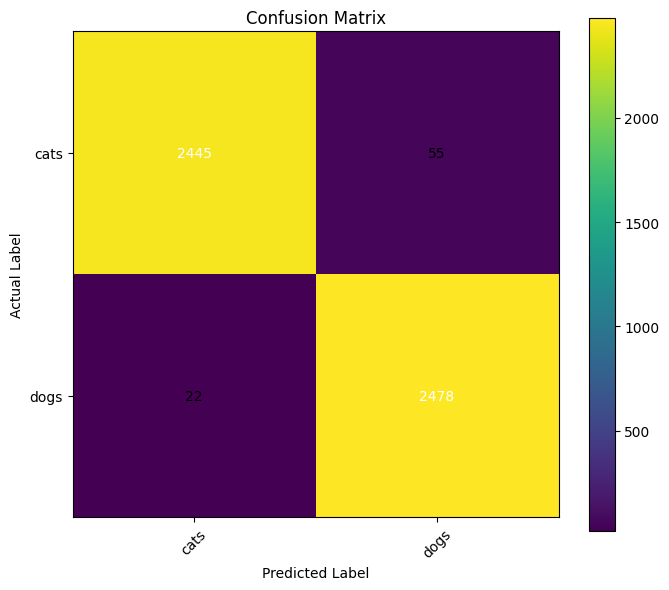

ERROR ANALYSIS
Total test images: 5000
Incorrectly classified images: 77


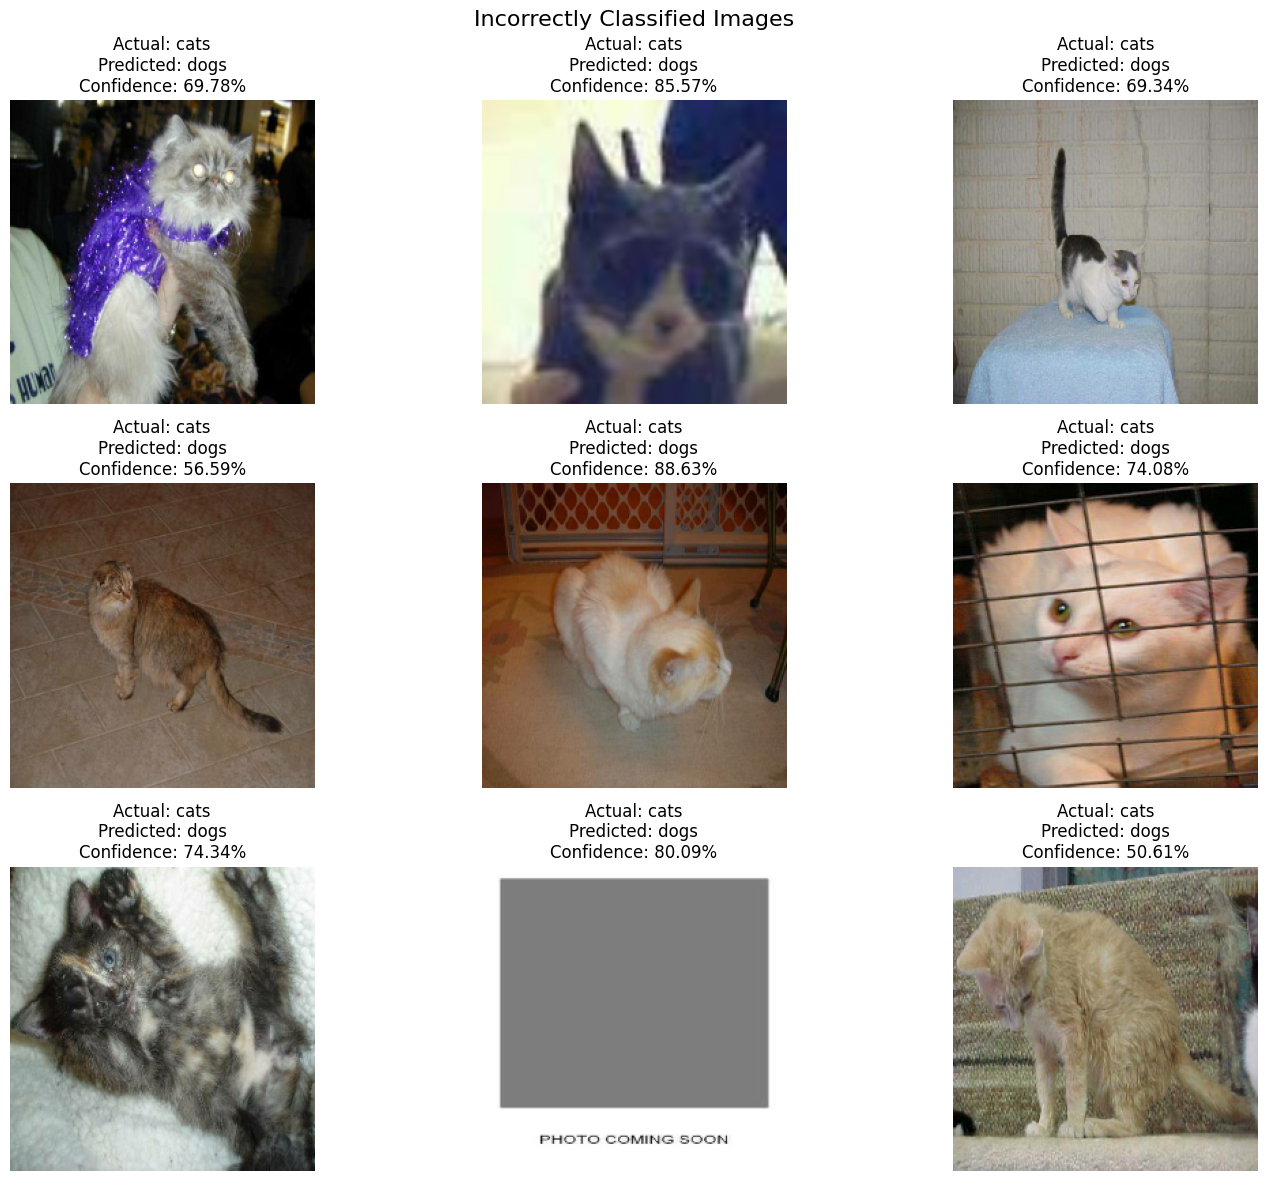

In [ ]:
# ============================================================
# RUN ERROR ANALYSIS
# ============================================================

error_analysis(
    fine_tuned_model,
    test_ds,
    class_names
)